Code to test the performance of shifting the data to account for misclassification errors from diffusion time in the testing environment.

In [61]:
from pathlib import Path

ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR.joinpath('data')
ONNX_MODEL_DIR = ROOT_DIR.joinpath('onnx_models')
INDICES_DIR = ROOT_DIR.joinpath("saved_indices")

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_fwf(DATA_DIR.joinpath("ethylene_methane.txt"), skiprows=1, header=None, names=["Time", "Methane ppm", "Ethylene ppm", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"])
df.insert(1, "Target", df["Methane ppm"] > 0)
print(df)

            Time  Target  Methane ppm  Ethylene ppm       S1       S2  \
0           0.00   False          0.0           0.0   -41.98  2067.64   
1           0.01   False          0.0           0.0   -46.50  2067.88   
2           0.02   False          0.0           0.0   -36.16  2055.81   
3           0.03   False          0.0           0.0   -50.36  2053.68   
4           0.04   False          0.0           0.0   -37.30  2081.17   
...          ...     ...          ...           ...      ...      ...   
4178499  4179.00   False          0.0           0.0  2348.00  1599.20   
4178500  4179.00   False          0.0           0.0  2341.00  1605.30   
4178501  4179.00   False          0.0           0.0  2345.00  1604.00   
4178502  4179.00   False          0.0           0.0  2350.00  1594.80   
4178503  4179.00   False          0.0           0.0  2348.00  1598.80   

              S3       S4       S5       S6       S7       S8       S9  \
0         -37.13     2.28     8.63   -26.62    -8

In [3]:
print("Number of True targets:", len(df[df['Target'].isin([True])]))
print("Number of False targets:", len(df[df['Target'].isin([False])]))

Number of True targets: 1849752
Number of False targets: 2328752


In [4]:
df.insert(1, "Target_shifted_22", df["Target"].shift(2200))
df.insert(1, "Target_shifted_21", df["Target"].shift(2100))
df.insert(1, "Target_shifted_20", df["Target"].shift(2000))
df.insert(1, "Target_shifted_19", df["Target"].shift(1900))
df.insert(1, "Target_shifted_18", df["Target"].shift(1800))

In [5]:
print(df.iloc[1999:2002])

      Time Target_shifted_18 Target_shifted_19 Target_shifted_20  \
1999  19.9             False             False               NaN   
2000  20.0             False             False             False   
2001  20.0             False             False             False   

     Target_shifted_21 Target_shifted_22  Target  Methane ppm  Ethylene ppm  \
1999               NaN               NaN   False          0.0           0.0   
2000               NaN               NaN   False          0.0           0.0   
2001               NaN               NaN   False          0.0           0.0   

          S1  ...      S7      S8       S9      S10      S11      S12  \
1999  2555.9  ...  4286.7  4840.9  3500.92  2781.36  3625.48  3613.70   
2000  2559.5  ...  4289.0  4833.4  3503.30  2791.47  3638.18  3606.17   
2001  2554.1  ...  4291.7  4861.4  3503.30  2782.16  3617.62  3598.03   

          S13      S14      S15      S16  
1999  3913.04  4516.24  3294.67  2876.99  
2000  3913.67  4510.41  3306.19

In [32]:
shift18 = df[["Target_shifted_18", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
shift19 = df[["Target_shifted_19", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
shift20 = df[["Target_shifted_20", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
shift21 = df[["Target_shifted_21", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()
shift22 = df[["Target_shifted_22", "S1", "S2", "S3", "S4", "S5", "S6", "S7", "S8", "S9", "S10", "S11", "S12", "S13", "S14", "S15", "S16"]].to_numpy()

shift18 = np.delete(shift18, np.s_[0:1800], axis=0)
shift19 = np.delete(shift19, np.s_[0:1900], axis=0)
shift20 = np.delete(shift20, np.s_[0:2000], axis=0)
shift21 = np.delete(shift21, np.s_[0:2100], axis=0)
shift22 = np.delete(shift22, np.s_[0:2200], axis=0)

In [46]:
datasets = [shift18, shift19, shift20, shift21, shift22]

In [7]:
import xgboost as xgb

In [8]:
spw = len(df[df['Target'].isin([False])]) / len(df[df['Target'].isin([True])])

model = xgb.XGBClassifier(
    n_estimators=3000, max_depth=3, learning_rate=0.01,
    scale_pos_weight=spw, tree_method="hist",
    subsample=0.5, colsample_bytree=0.5, min_child_weight=100,
    gamma=2.0, reg_alpha=0.5, reg_lambda=10.0,
    objective="binary:logistic", eval_metric="logloss",
    early_stopping_rounds=50, random_state=42,
    n_jobs=-1, verbosity=0,
)

In [59]:
from sklearn.metrics import accuracy_score
accuracy_scores = []
split = [.7, .15, .15]
for dataset in datasets:
    length = len(dataset)

    train_end = int(length * split[0])
    test_end = int(train_end + length * split[1])

    xtrain = dataset[:train_end, 1:]
    ytrain = dataset[:train_end, 0]
    xtest = dataset[train_end:test_end, 1:]
    ytest = dataset[train_end:test_end, 0]
    xval = dataset[test_end:length, 1:]
    yval = dataset[test_end:length, 0]

    model.fit(xtrain, ytrain, eval_set=[(xtrain, ytrain), (xtest, ytest)])
    ypred = model.predict(xval)
    accuracy = accuracy_score(list(map(int,yval)), ypred)
    accuracy_scores.append(accuracy)

[0]	validation_0-logloss:0.68859	validation_1-logloss:0.69241
[1]	validation_0-logloss:0.67935	validation_1-logloss:0.68294
[2]	validation_0-logloss:0.67026	validation_1-logloss:0.67364
[3]	validation_0-logloss:0.66140	validation_1-logloss:0.66508
[4]	validation_0-logloss:0.65267	validation_1-logloss:0.65608
[5]	validation_0-logloss:0.64411	validation_1-logloss:0.64725
[6]	validation_0-logloss:0.63575	validation_1-logloss:0.63865
[7]	validation_0-logloss:0.62757	validation_1-logloss:0.63031
[8]	validation_0-logloss:0.61949	validation_1-logloss:0.62201
[9]	validation_0-logloss:0.61155	validation_1-logloss:0.61388
[10]	validation_0-logloss:0.60377	validation_1-logloss:0.60590
[11]	validation_0-logloss:0.59612	validation_1-logloss:0.59812
[12]	validation_0-logloss:0.58861	validation_1-logloss:0.59039
[13]	validation_0-logloss:0.58125	validation_1-logloss:0.58280
[14]	validation_0-logloss:0.57403	validation_1-logloss:0.57536
[15]	validation_0-logloss:0.56692	validation_1-logloss:0.56806
[1

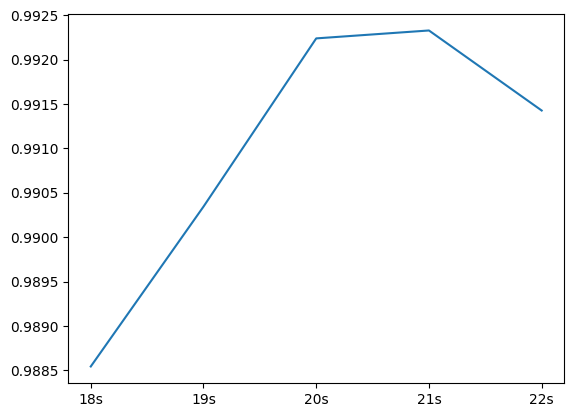

In [66]:
plt.plot(["18s", "19s", "20s", "21s", "22s"], accuracy_scores)